<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_ResNet
Custom lightweight ResNet trained from scratch on VWW.
Comparison baseline.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import VWW_MobileNetV2, VWW_VGGStyle, VWW_ResNet, count_params, model_size_mb
from utils.train   import setup_device, set_seed, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [4]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [5]:
results, best = train_multi_seed(
    model_fn     = VWW_ResNet,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "resnet",
    pretrained   = False,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1   # consistent with all other scratch models,
    patience        = 8,
)


Seed 41
Epoch   1/50 | LR 0.000999 | Train 58.10% | Val 61.53% ✅
Epoch   2/50 | LR 0.000996 | Train 61.43% | Val 62.33% ✅
Epoch   3/50 | LR 0.000991 | Train 62.81% | Val 62.27%
Epoch   4/50 | LR 0.000984 | Train 64.97% | Val 56.67%
Epoch   5/50 | LR 0.000976 | Train 66.46% | Val 63.60% ✅
Epoch   6/50 | LR 0.000965 | Train 66.76% | Val 67.87% ✅
Epoch   7/50 | LR 0.000952 | Train 67.51% | Val 66.60%
Epoch   8/50 | LR 0.000938 | Train 69.29% | Val 69.13% ✅
Epoch   9/50 | LR 0.000922 | Train 68.39% | Val 67.93%
Epoch  10/50 | LR 0.000905 | Train 69.66% | Val 67.80%
Epoch  11/50 | LR 0.000885 | Train 69.03% | Val 69.67% ✅
Epoch  12/50 | LR 0.000864 | Train 69.90% | Val 70.33% ✅
Epoch  13/50 | LR 0.000842 | Train 71.21% | Val 69.80%
Epoch  14/50 | LR 0.000819 | Train 70.67% | Val 70.47% ✅
Epoch  15/50 | LR 0.000794 | Train 72.09% | Val 71.33% ✅
Epoch  16/50 | LR 0.000768 | Train 72.76% | Val 66.73%
Epoch  17/50 | LR 0.000741 | Train 72.21% | Val 72.47% ✅
Epoch  18/50 | LR 0.000713 | Train 7

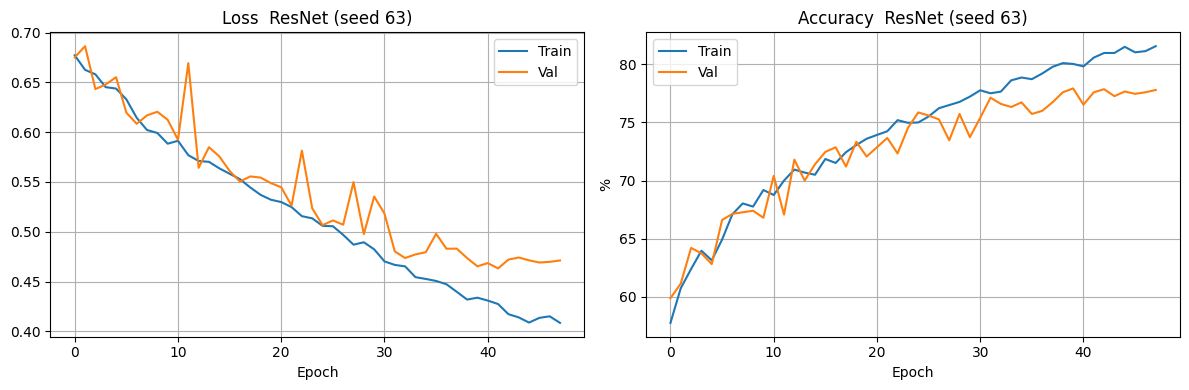

Best: 77.93% @ epoch 40  (20.2 min)

ResNet  |  Mean: 76.52% ± 1.75%  |  Best: 77.93% (seed 63)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/resnet_seed_63.pth


In [6]:
plot_history(best, title=f"ResNet (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nResNet  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")